
# Dropout in ANN — Regression

## 1. What is Dropout?

**Dropout** is a **regularization technique** used to reduce overfitting.

During training, it randomly deactivates a fraction of neurons.

```python
Dropout(0.2)
```

→ Approximately **20% of neurons are randomly deactivated** during each training iteration.

This prevents **co-adaptation** between neurons and forces the model to learn more robust patterns.

> Dropout is active during training and disabled during inference/testing.

---

## 2. Regression Experiment

### Architecture

```text
Input
  ↓
Dense(128, ReLU)
  ↓
Dense(128, ReLU)
  ↓
Dense(1, Linear)
```

**Training:** Adam (`lr=0.01`), MSE loss, 500 epochs.

### Without Dropout

The model **overfits** the noisy training data.

- Training Loss ≈ **0.03**
- Testing Loss ≈ **0.10**
- Prediction curve becomes highly irregular and fits noise.

```text
Low Training Loss + High Testing Loss
                ↓
           Overfitting
```

### With Dropout = 0.2

```python
Dense(128, activation="relu")
Dropout(0.2)

Dense(128, activation="relu")
Dropout(0.2)

Dense(1, activation="linear")
```

Results:

- Training Loss increases slightly → ≈ **0.09**
- Testing Loss decreases.
- Training and testing losses become closer.
- Prediction curve becomes smoother.
- Better generalization.

> **Important:** Higher training loss after regularization is acceptable if validation/testing performance improves.

---

## 3. Effect of Dropout Rate

| Dropout $p$ | Effect |
|---|---|
| **$p=0$** | Full capacity → **Overfitting** |
| **$p=0.2-0.5$** | Good regularization → **Better Generalization** |
| **Very high $p$** | Too much capacity removed → **Underfitting** |

$$
\text{Low Dropout} \rightarrow \text{Overfitting}
$$

$$
\text{Moderate Dropout} \rightarrow \text{Better Generalization}
$$

$$
\text{High Dropout} \rightarrow \text{Underfitting}
$$

---

## 4. How to Choose Dropout?

- **Overfitting** → Increase dropout.
- **Underfitting** → Decrease dropout.
- Practical starting range: **0.2–0.5**, then tune experimentally.

### Dropout Placement

It does not need to be added after every layer.

Common approach:

```text
Dense
  ↓
Dense
  ↓
Dropout
  ↓
Output
```

---

## 5. Advantages & Drawbacks

### Advantages

- Reduces overfitting.
- Prevents neuron co-adaptation.
- Improves generalization.
- Helps produce smoother predictions.

### Drawbacks

- Can make convergence slower.
- Training becomes more difficult to analyze because the active network changes every iteration.

---

## 6. Key Takeaways

- Dropout = **regularization technique**.
- `Dropout(p)` randomly deactivates approximately **$p$ fraction of neurons during training**.
- It reduces the model's effective capacity.
- **Too little → overfitting.**
- **Too much → underfitting.**
- The goal is **better validation/testing performance**, not simply lower training loss.
```



In [2]:
import numpy as np 
import matplotlib.pyplot as plt  
import tensorflow 

from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense ,Input , Dropout 
from tensorflow.keras.optimizers import Adam 

from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error 

# Generate Data

In [3]:
x_train = np.linspace(-1, 1, 20)

In [4]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [5]:
x_test = np.linspace(-1, 1, 20)

In [6]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

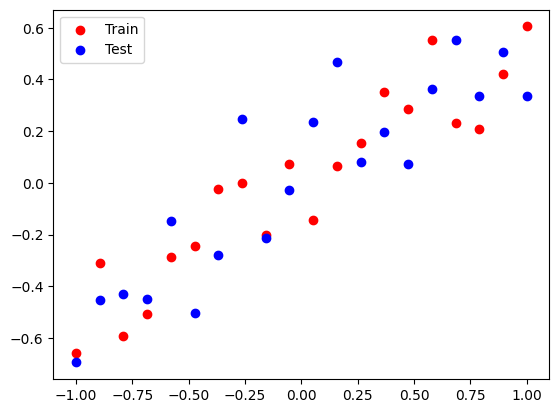

In [7]:
plt.scatter(x_train, y_train, c='red', label='Train')
plt.scatter(x_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

# Regression Model 

In [22]:
model_1 = Sequential([
    Input(shape=(1,)), 
    Dense(128,activation="relu"), 
    Dense(128,activation="relu"), 
    Dense(1, activation="linear")
])

adam = Adam(learning_rate=0.01)

model_1.compile(loss='mse', optimizer=adam, metrics=['mse'])

history = model_1.fit(x_train, y_train, epochs=500, 
                    validation_data = (x_test, y_test),
                    verbose=False)

In [18]:
# Evaluate model 

_, train_mse = model_1.evaluate(x_train, y_train, verbose=0)
_, test_mse = model_1.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.002556899096816778, Test: 0.04597652330994606


In [19]:
y_pred_1 = model_1.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


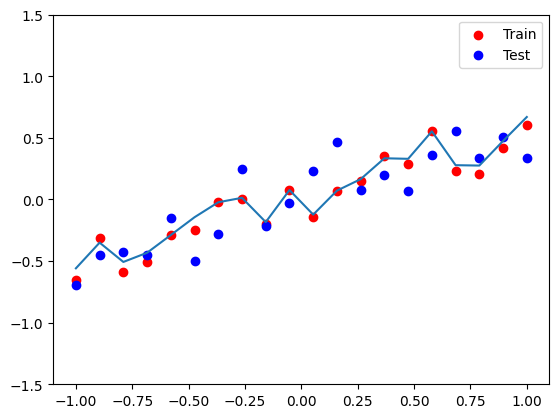

In [20]:
plt.figure()
plt.scatter(x_train, y_train, c='red', label='Train')
plt.scatter(x_test, y_test, c='blue', label='Test')
plt.plot(x_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

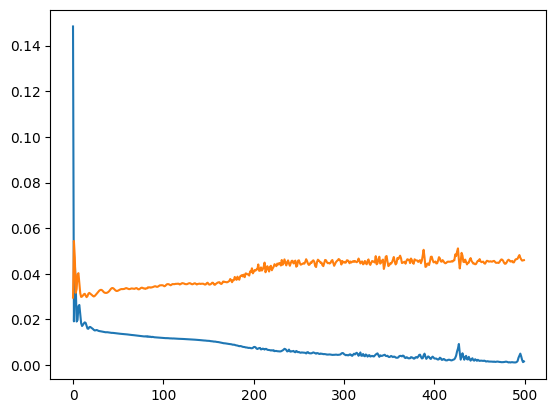

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Dropout Model

In [12]:
model_2 = Sequential([
    Input(shape=(1,)), 
    Dense(128,activation="relu"),
    Dropout(0.2),
    Dense(128,activation="relu"),
    Dropout(0.2),
    Dense(1, activation="linear")
])

adam = Adam(learning_rate=0.01)
model_2.compile(loss='mse', optimizer=adam, metrics=['mse'])

drop_out_history = model_2.fit(x_train, y_train, epochs=500, 
                               validation_data = (x_test, y_test),
                               verbose=False)

In [14]:
# evaluate the model
_, train_mse = model_2.evaluate(x_train, y_train, verbose=0)
_, test_mse = model_2.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.011652235873043537, Test: 0.03658237308263779


In [15]:
y_pred_2 = model_2.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


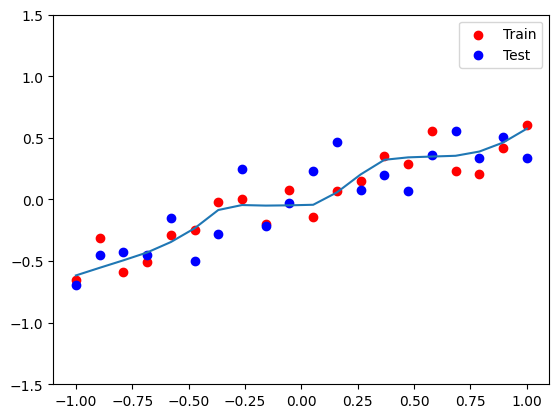

In [16]:
plt.figure()
plt.scatter(x_train, y_train, c='red', label='Train')
plt.scatter(x_test, y_test, c='blue', label='Test')
plt.plot(x_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

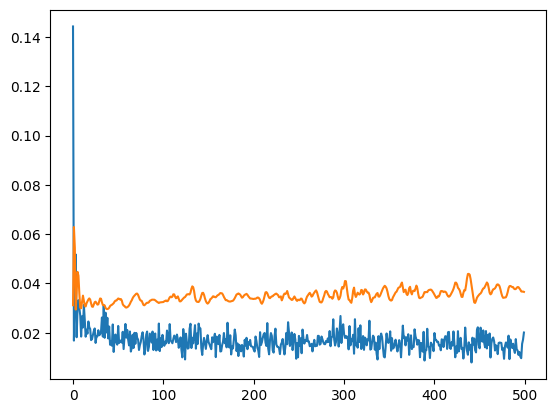

In [25]:
plt.plot(drop_out_history.history['loss'])
plt.plot(drop_out_history.history['val_loss'])